<a href="https://colab.research.google.com/github/miajags/EMSC2010-W10-P1-time-series-analysis/blob/main/EMSC2010_W10_L1_NB4_cherry_blossoms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [3]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [5]:
# ADD YOUR CODE HERE

file = 'blossom_doy.xlsx' #define the name of the data file
df = pd.read_excel(file) #read the file into a dataframe
df.head() #show the dataframe header


,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


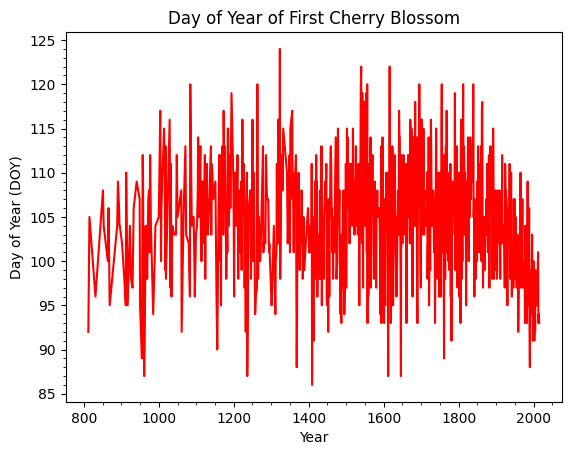

In [31]:
#plot

year = df['year'].values #get the month data as a numpy array
doy = df['doy'].values #get the runoff data as a numpy array
plt.plot(year,doy,'r') #plot the data
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year (DOY)') #label the y-axis
plt.minorticks_on() #add minor ticks to the plot
plt.title('Day of Year of First Cherry Blossom') #add a title to the plot
plt.show() #show the plot

## plotted data

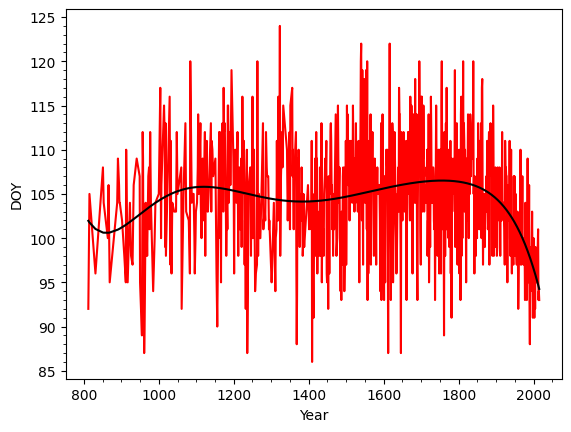

In [18]:
#plot with regression/polynomial

order = 7 #set the polynomial order
pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

plt.plot(year,doy,'r') #plot the data
plt.plot(year,trend,'k') #plot the trend
plt.xlabel('Year') #label the x-axis
plt.ylabel('DOY') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

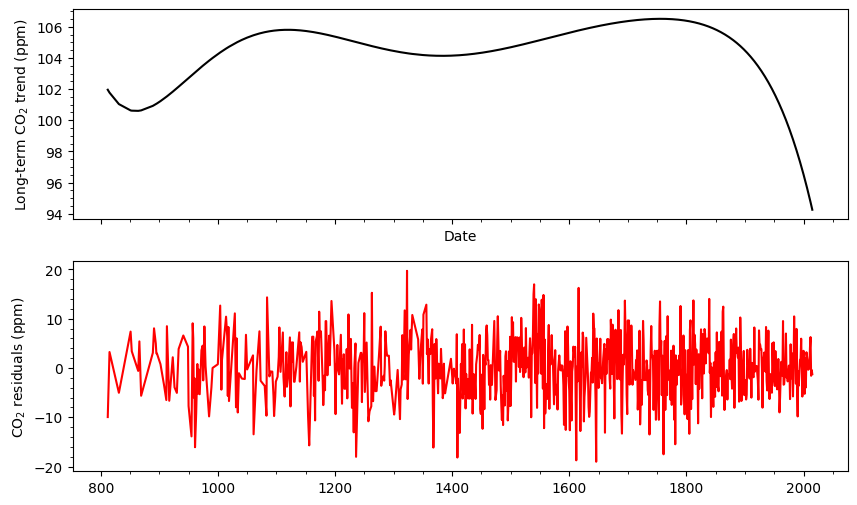

In [32]:
residuals = doy-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(year,trend,'k') #plot the polynomial trend
axes[1].plot(year,residuals,'r') #plot the residuals

axes[0].set_xlabel('Date') #label the x-axis
axes[0].set_ylabel('Long-term CO$_2$ trend (ppm)') #label the trend y-axis
axes[1].set_ylabel('CO$_2$ residuals (ppm)') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

## differences between data and fitted polynomial trend

In [33]:
## now doing a moving average analysis

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

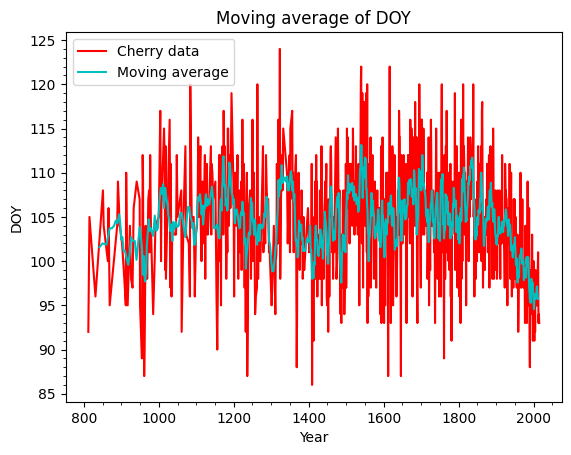

In [34]:
#moving average

w = 7 #length of the moving average, usually use odd numbers
ys = moving_average(doy, w) #process the signal
ts = moving_average(year, w) #process the times

plt.plot(year,doy,'r',label='Cherry data') #plot the original sine wave
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average
plt.xlabel('Year') #label the x-axis
plt.ylabel('DOY') #label the y-axis
plt.title('Moving average of DOY') #add a title
plt.legend() #add a legend
plt.minorticks_on() #add minorticks

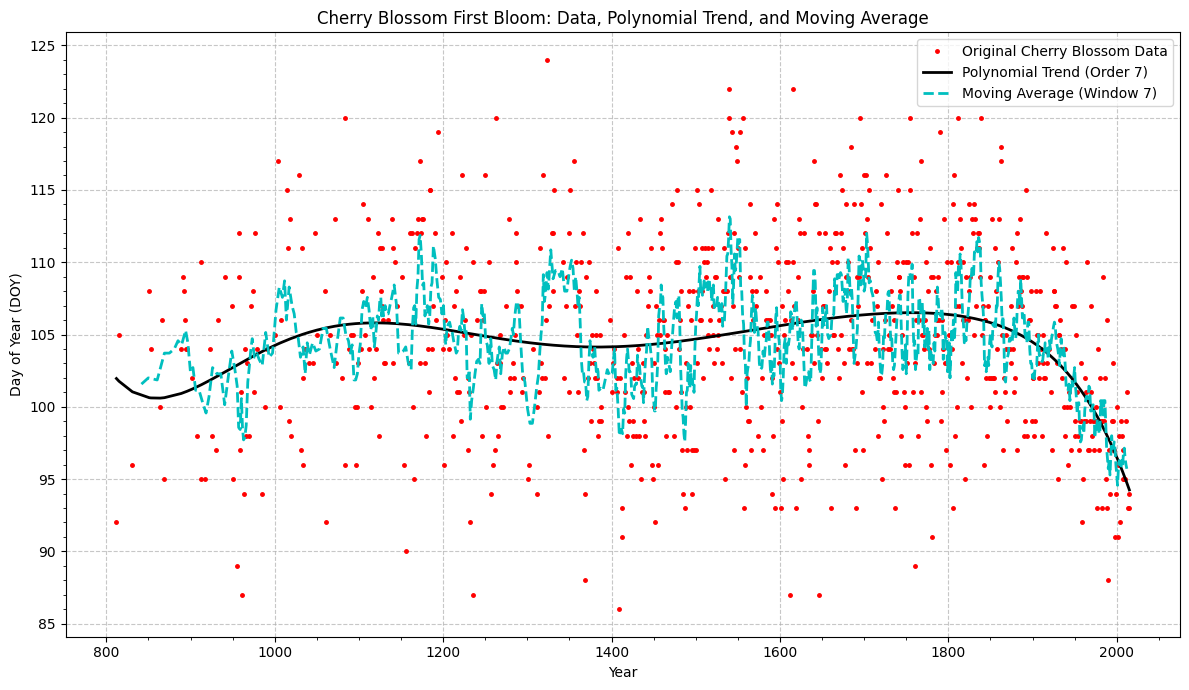

In [36]:
## AI to combine regression, moving average and original data plot

plt.figure(figsize=(12, 7))
plt.plot(year, doy, 'r.', markersize=5, label='Original Cherry Blossom Data') # Plot original data as points
plt.plot(year, trend, 'k-', linewidth=2, label=f'Polynomial Trend (Order {order})') # Plot polynomial trend
plt.plot(ts, ys, 'c--', linewidth=2, label=f'Moving Average (Window {w})') # Plot moving average

plt.xlabel('Year') # Label the x-axis
plt.ylabel('Day of Year (DOY)') # Label the y-axis
plt.title('Cherry Blossom First Bloom: Data, Polynomial Trend, and Moving Average') # Add a title
plt.legend() # Add a legend to distinguish the lines
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.minorticks_on() # Add minor ticks to the plot
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show() # Display the plot

# Interpretation!

- trend: there is a big dip in the trend from around year 1800 that the cherry blossoms are beginning earlier and earlier each year
- assumption that due to industrialisation, human fossil fuel use and global warming, temperatures are getting warmer, spring is beginning sooner and sooner, and thus the cherry blossoms are beginning earlier.
- cherry blossoms opening sooner due to warming global climate